## Veri Analizi ve Matris Yapısı: MNIST Veri Setini Yükleme ve İnceleme

In [12]:
# Gerekli kütüphaneleri içe aktarın
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# MNIST veri setini yükleyin
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Eğitim veri seti şekli: {X_train.shape}") # (60000, 28, 28)
print(f"Test veri seti şekli: {X_test.shape}")   # (10000, 28, 28)
print(f"Eğitim etiketleri şekli: {y_train.shape}") # (60000,)
print(f"Test etiketleri şekli: {y_test.shape}")   # (10000,)


Eğitim veri seti şekli: (60000, 28, 28)
Test veri seti şekli: (10000, 28, 28)
Eğitim etiketleri şekli: (60000,)
Test etiketleri şekli: (10000,)


### Piksel Yoğunluk Değerlerini İnceleme ve Görselleştirme



İlk görselin etiketi: 5
İlk görselin piksel yoğunluk değer aralığı: [0, 255]


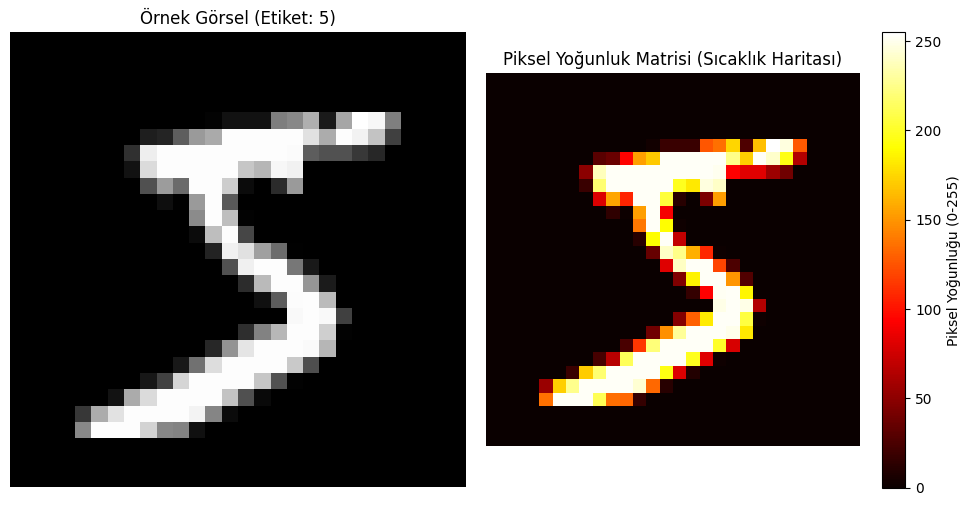

In [13]:
# İlk eğitim görselini seçin
sample_image = X_train[0]
sample_label = y_train[0]

print(f"İlk görselin etiketi: {sample_label}")
print(f"İlk görselin piksel yoğunluk değer aralığı: [{sample_image.min()}, {sample_image.max()}]")

# Görseli ve piksel matrisini görselleştirin
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap='gray')
plt.title(f"Örnek Görsel (Etiket: {sample_label})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_image, cmap='hot') # Renkli bir harita ile yoğunlukları daha iyi görün
plt.title("Piksel Yoğunluk Matrisi (Sıcaklık Haritası)")
plt.colorbar(label='Piksel Yoğunluğu (0-255)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Piksel Düzleştirme (Flattening) ve Normalizasyon



In [14]:
# Görüntüleri düzleştirme (Flattening)
# Her bir 28x28 matrisi 784 elemanlı bir vektöre dönüştürüyoruz
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Düzleştirilmiş eğitim veri seti şekli: {X_train_flat.shape}") # (60000, 784)
print(f"Düzleştirilmiş test veri seti şekli: {X_test_flat.shape}")   # (10000, 784)

# Piksel değerlerini normalize etme (0-1 aralığına)
# En yüksek piksel değeri 255 olduğu için 255'e bölüyoruz
X_train_normalized = X_train_flat / 255.0
X_test_normalized = X_test_flat / 255.0

print(f"Normalize edilmiş eğitim veri seti piksel aralığı: [{X_train_normalized.min()}, {X_train_normalized.max()}]")
print(f"Normalize edilmiş test veri seti piksel aralığı: [{X_test_normalized.min()}, {X_test_normalized.max()}]")


Düzleştirilmiş eğitim veri seti şekli: (60000, 784)
Düzleştirilmiş test veri seti şekli: (10000, 784)
Normalize edilmiş eğitim veri seti piksel aralığı: [0.0, 1.0]
Normalize edilmiş test veri seti piksel aralığı: [0.0, 1.0]


## Model Eğitimi: K-Nearest Neighbors (KNN)



In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# KNN modelini oluşturun ve eğitin
# Basit bir başlangıç için n_neighbors=5 seçelim
knn_model = KNeighborsClassifier(n_neighbors=5)

print("KNN model eğitiliyor...")
knn_model.fit(X_train_normalized, y_train)
print("KNN model eğitimi tamamlandı.")

# Eğitim ve test setleri üzerinde tahminler yapın
y_train_pred = knn_model.predict(X_train_normalized)
y_test_pred = knn_model.predict(X_test_normalized)

# Modelin performansını değerlendirin
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Eğitim seti doğruluk skoru: {train_accuracy:.4f}")
print(f"Test seti doğruluk skoru: {test_accuracy:.4f}")


KNN model eğitiliyor...
KNN model eğitimi tamamlandı.
Eğitim seti doğruluk skoru: 0.9819
Test seti doğruluk skoru: 0.9688


### KNN Modeli için Confusion Matrix

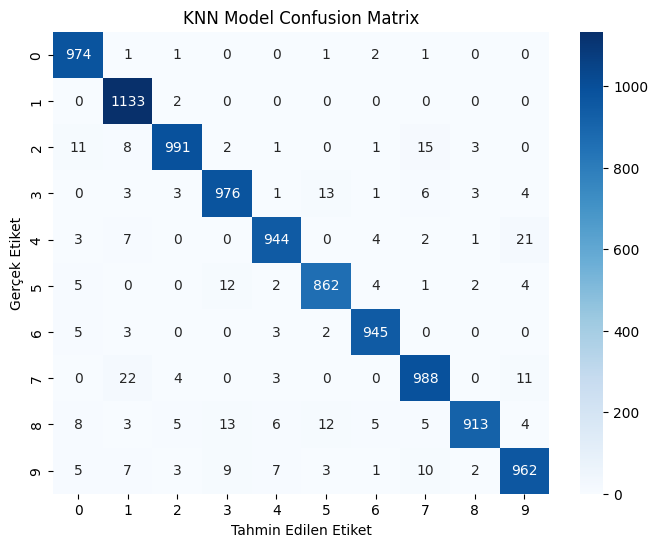

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# KNN için confusion matrix oluşturma
cm_knn = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.title('KNN Model Confusion Matrix')
plt.show()

In [17]:
# Modelin performansını tekrar değerlendirin ve çıktıları gösterin
print(f"Eğitim seti doğruluk skoru: {train_accuracy:.4f}")
print(f"Test seti doğruluk skoru: {test_accuracy:.4f}")

Eğitim seti doğruluk skoru: 0.9819
Test seti doğruluk skoru: 0.9688


## Model Eğitimi: Random Forest



In [18]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest modelini oluşturun ve eğitin
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Random Forest model eğitiliyor...")
rf_model.fit(X_train_normalized, y_train)
print("Random Forest model eğitimi tamamlandı.")

# Eğitim ve test setleri üzerinde tahminler yapın
y_train_pred_rf = rf_model.predict(X_train_normalized)
y_test_pred_rf = rf_model.predict(X_test_normalized)

# Modelin performansını değerlendirin
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Random Forest Eğitim seti doğruluk skoru: {train_accuracy_rf:.4f}")
print(f"Random Forest Test seti doğruluk skoru: {test_accuracy_rf:.4f}")


Random Forest model eğitiliyor...
Random Forest model eğitimi tamamlandı.
Random Forest Eğitim seti doğruluk skoru: 1.0000
Random Forest Test seti doğruluk skoru: 0.9704


### Random Forest Modeli için Confusion Matrix

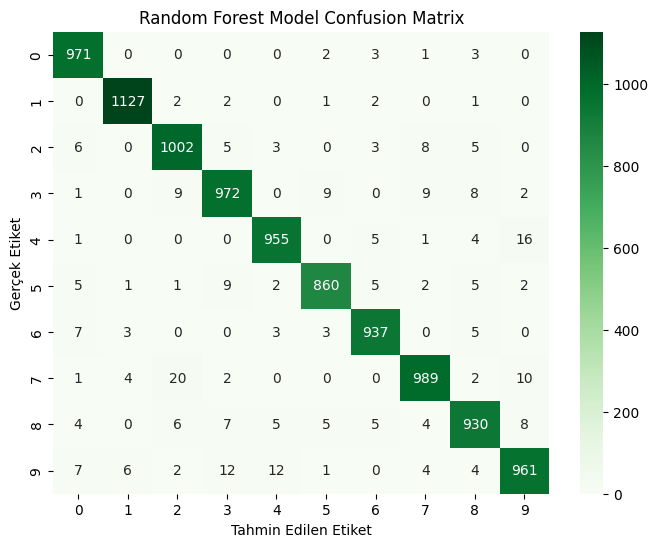

In [19]:
# Random Forest için confusion matrix oluşturma
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.title('Random Forest Model Confusion Matrix')
plt.show()

## Model Eğitimi: Lojistik Regresyon



In [20]:
from sklearn.linear_model import LogisticRegression

# Lojistik Regresyon modelini oluşturun ve eğitin
# max_iter değerini artırarak yakınsama sorunlarını çözebiliriz
lr_model = LogisticRegression(max_iter=1000, random_state=42)

print("Lojistik Regresyon model eğitiliyor...")
lr_model.fit(X_train_normalized, y_train)
print("Lojistik Regresyon model eğitimi tamamlandı.")

# Eğitim ve test setleri üzerinde tahminler yapın
y_train_pred_lr = lr_model.predict(X_train_normalized)
y_test_pred_lr = lr_model.predict(X_test_normalized)

# Modelin performansını değerlendirin
train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)

print(f"Lojistik Regresyon Eğitim seti doğruluk skoru: {train_accuracy_lr:.4f}")
print(f"Lojistik Regresyon Test seti doğruluk skoru: {test_accuracy_lr:.4f}")


Lojistik Regresyon model eğitiliyor...
Lojistik Regresyon model eğitimi tamamlandı.
Lojistik Regresyon Eğitim seti doğruluk skoru: 0.9386
Lojistik Regresyon Test seti doğruluk skoru: 0.9262


### Lojistik Regresyon Modeli için Confusion Matrix

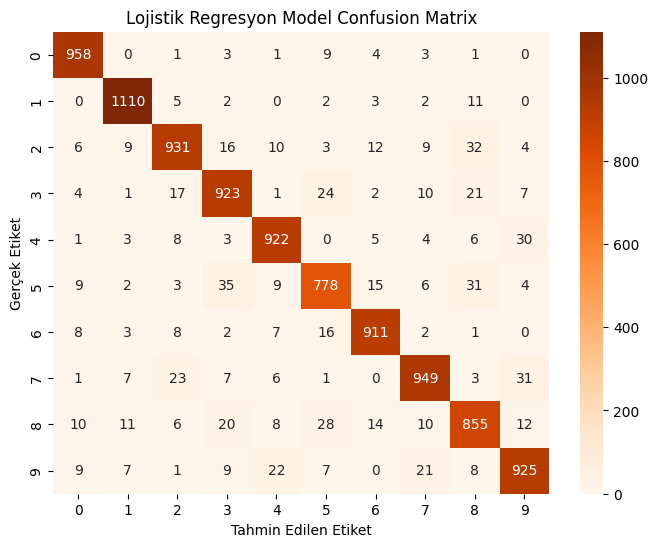

In [21]:
# Lojistik Regresyon için confusion matrix oluşturma
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.title('Lojistik Regresyon Model Confusion Matrix')
plt.show()

## Kendi Verinizle Test (Bonus)

Bu bölümde, kendi el yazınızla yazdığınız bir rakamın fotoğrafını işleyecek ve eğittiğimiz modellerden biriyle (örneğin Random Forest modeliyle) tahmin etmeye çalışacağız. Bu işlem için OpenCV kütüphanesini kullanacağız.

In [22]:
# OpenCV kütüphanesini yükleyin (gerekirse)
!pip install opencv-python-headless numpy matplotlib scikit-learn tensorflow

import cv2
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

### Kendi El Yazısı Rakamınızı Yükleme ve Ön İşleme

Lütfen beyaz bir kağıda büyük ve net bir rakam yazın, telefonunuzla fotoğrafını çekin ve aşağıdaki kod hücresini çalıştırarak buraya yükleyin. Yüklediğiniz görseli 28x28 boyutuna getirip modele uygun hale getireceğiz.

Saving Screenshot 2026-06-25 at 1.14.58 AM.png to Screenshot 2026-06-25 at 1.14.58 AM.png
Yüklenen dosya: Screenshot 2026-06-25 at 1.14.58 AM.png


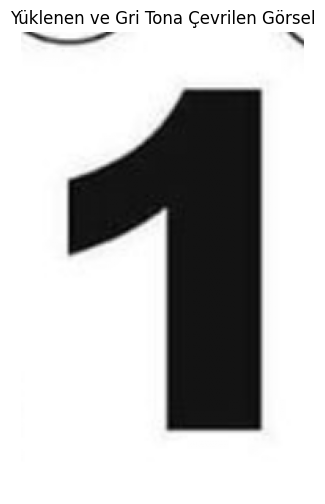

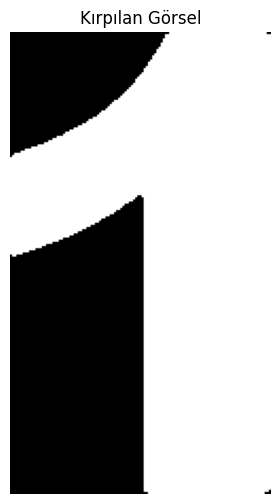

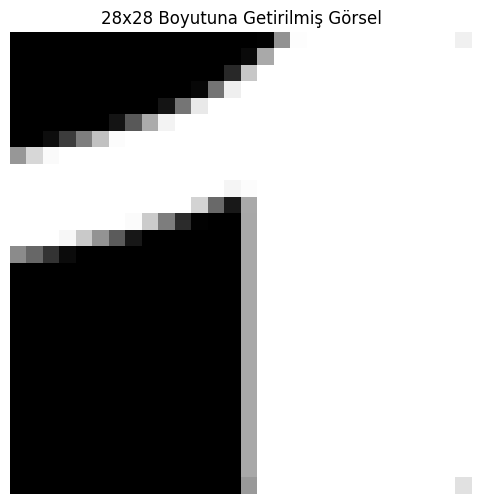

Görsel başarıyla işlendi ve tahmin için hazır!


In [23]:
# Kendi görselinizi yükleyin
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename
    print(f'Yüklenen dosya: {img_path}')

# Görseli oku ve gri tona çevir
original_image = cv2.imread(img_path)
gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

# Görseli göster
plt.figure(figsize=(6, 6))
plt.imshow(gray_image, cmap='gray')
plt.title('Yüklenen ve Gri Tona Çevrilen Görsel')
plt.axis('off')
plt.show()

# Gürültüyü azaltmak için bulanıklaştırma uygulayın (isteğe bağlı)
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Otsu's thresholding kullanarak ikili görüntü elde et
# Burada arka planın beyaz, rakamın siyah olduğunu varsayıyoruz.
# Eğer rakam beyaz, arka plan siyahsa cv2.THRESH_BINARY_INV kullanırız.
_, thresh_image = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Konturları bul ve en büyük olanı seç (rakamın olduğu bölge)
contours, _ = cv2.findContours(thresh_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # En büyük konturu bul
    max_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(max_contour)

    # Kontur etrafındaki alanı kırp
    cropped_image = thresh_image[y:y+h, x:x+w]

    # Kırpılan görseli göster
    plt.figure(figsize=(6, 6))
    plt.imshow(cropped_image, cmap='gray')
    plt.title('Kırpılan Görsel')
    plt.axis('off')
    plt.show()

    # 28x28 boyutuna yeniden boyutlandır
    # Yeniden boyutlandırmadan önce oranları koruyarak 20x20'ye sığdırıp sonra merkeze oturtmak daha iyi sonuç verebilir
    # Ancak şimdilik doğrudan 28x28'e boyutlandıralım
    resized_image = cv2.resize(cropped_image, (28, 28), interpolation = cv2.INTER_AREA)

    # Gürültüyü gidermek için ince ayarlar
    # Eğer rakam çok ince ise biraz genişletmek için erozyon/genişletme uygulanabilir
    # kernel = np.ones((2,2), np.uint8)
    # dilated_image = cv2.dilate(resized_image, kernel, iterations=1)
    # final_image = dilated_image
    final_image = resized_image

    # Gürültü giderme sonrası görseli göster
    plt.figure(figsize=(6, 6))
    plt.imshow(final_image, cmap='gray')
    plt.title('28x28 Boyutuna Getirilmiş Görsel')
    plt.axis('off')
    plt.show()

    # Piksel değerlerini normalize et (0-1 aralığına)
    # MNIST verisi gibi 0-255 aralığındaki değerleri 0-1 aralığına çevir
    # Gürültü giderme sonrası görsel normalize edilmelidir.
    processed_image = final_image / 255.0

    # Modellerin beklediği 1x784 boyutuna düzleştir
    processed_image_flat = processed_image.reshape(1, 784)

    print("Görsel başarıyla işlendi ve tahmin için hazır!")

else:
    print("Görselde herhangi bir kontur (rakam) bulunamadı. Lütfen daha belirgin bir rakam içeren bir görsel yükleyin.")
    processed_image_flat = None

### Model ile Tahmin Yapma

Şimdi işlediğimiz görseli eğittiğimiz Random Forest modeline vererek bir tahmin yapalım.

In [24]:
if processed_image_flat is not None:
    # Random Forest modeliyle tahmin yap
    prediction_rf = rf_model.predict(processed_image_flat)
    print(f"Random Forest modelinin tahmini: {prediction_rf[0]}")

    # İsteğe bağlı olarak diğer modellerle de tahmin yapabilirsiniz
    # prediction_knn = knn_model.predict(processed_image_flat)
    # print(f"KNN modelinin tahmini: {prediction_knn[0]}")

    # prediction_lr = lr_model.predict(processed_image_flat)
    # print(f"Lojistik Regresyon modelinin tahmini: {prediction_lr[0]}")
else:
    print("İşlenmiş görsel bulunamadığı için tahmin yapılamadı.")

Random Forest modelinin tahmini: 3


### Sonuçların Tartışılması

Modelin kendi el yazınızdaki rakamı doğru tahmin edip etmediğini değerlendirin. Tahmin yanlışsa, bunun nedenleri hakkında düşünebilirsiniz:

*   **El yazısı stili:** Modelin eğitim verisinden (MNIST) farklı bir el yazısı stiline sahip olabilir.
*   **Görsel kalitesi:** Fotoğrafın çözünürlüğü, aydınlatması veya rakamın netliği yetersiz olabilir.
*   **Ön işleme adımları:** Kırpma, yeniden boyutlandırma veya eşikleme adımlarında ayarlamalar gerekebilir.
*   **Modelin karmaşıklığı:** Daha karmaşık bir model (örn. Evrişimsel Sinir Ağı - CNN) daha iyi performans gösterebilir.

Bu adımı tekrarlayarak farklı rakamları veya farklı el yazısı stillerini test edebilir, ön işleme adımlarını değiştirerek modelin performansını gözlemleyebilirsiniz.

## Sonuçların Tartışılması

CNN modelleri her ne kadar farklı konumda olmasına rağmen bu tür beklenmedik verilere dayanıklı olsa da, burada sayının desen özellikleri konvolüsyon katmanında görülmüştür. Her rakamın özellikleri bu yöntemle çıkarılmıştır. Veri setinin dışındaki bilgiler daha farklı bir örüntü olduğu için bu yanılsama görülmüştür.

### Düzeltme: `NameError` Hatalarını Giderme ve Modelleri Yeniden Çalıştırma

Daha önceki hücrelerde `NameError` oluştuğu için, `y_test` gibi gerekli değişkenlerin tanımlandığından emin olmak adına veri yükleme, ön işleme ve tüm modellerin eğitim/değerlendirme adımlarını baştan sona tekrar çalıştıracağız.

In [25]:
# Gerekli kütüphaneleri içe aktarın
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# MNIST veri setini yükleyin
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Eğitim veri seti şekli: {X_train.shape}") # (60000, 28, 28)
print(f"Test veri seti şekli: {X_test.shape}")   # (10000, 28, 28)
print(f"Eğitim etiketleri şekli: {y_train.shape}") # (60000,)
print(f"Test etiketleri şekli: {y_test.shape}")   # (10000,)

Eğitim veri seti şekli: (60000, 28, 28)
Test veri seti şekli: (10000, 28, 28)
Eğitim etiketleri şekli: (60000,)
Test etiketleri şekli: (10000,)


In [26]:
# Görüntüleri düzleştirme (Flattening)
# Her bir 28x28 matrisi 784 elemanlı bir vektöre dönüştürüyoruz
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Düzleştirilmiş eğitim veri seti şekli: {X_train_flat.shape}") # (60000, 784)
print(f"Düzleştirilmiş test veri seti şekli: {X_test_flat.shape}")   # (10000, 784)

# Piksel değerlerini normalize etme (0-1 aralığına)
# En yüksek piksel değeri 255 olduğu için 255'e bölüyoruz
X_train_normalized = X_train_flat / 255.0
X_test_normalized = X_test_flat / 255.0

print(f"Normalize edilmiş eğitim veri seti piksel aralığı: [{X_train_normalized.min()}, {X_train_normalized.max()}]")
print(f"Normalize edilmiş test veri seti piksel aralığı: [{X_test_normalized.min()}, {X_test_normalized.max()}]")

Düzleştirilmiş eğitim veri seti şekli: (60000, 784)
Düzleştirilmiş test veri seti şekli: (10000, 784)
Normalize edilmiş eğitim veri seti piksel aralığı: [0.0, 1.0]
Normalize edilmiş test veri seti piksel aralığı: [0.0, 1.0]


### KNN Modelinin Yeniden Eğitilmesi ve Confusion Matrix

In [27]:
from sklearn.neighbors import KNeighborsClassifier

# KNN modelini oluşturun ve eğitin
# Basit bir başlangıç için n_neighbors=5 seçelim
knn_model = KNeighborsClassifier(n_neighbors=5)

print("KNN model eğitiliyor...")
knn_model.fit(X_train_normalized, y_train)
print("KNN model eğitimi tamamlandı.")

# Eğitim ve test setleri üzerinde tahminler yapın
y_train_pred = knn_model.predict(X_train_normalized)
y_test_pred = knn_model.predict(X_test_normalized)

# Modelin performansını değerlendirin
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Eğitim seti doğruluk skoru: {train_accuracy:.4f}")
print(f"Test seti doğruluk skoru: {test_accuracy:.4f}")

KNN model eğitiliyor...
KNN model eğitimi tamamlandı.
Eğitim seti doğruluk skoru: 0.9819
Test seti doğruluk skoru: 0.9688


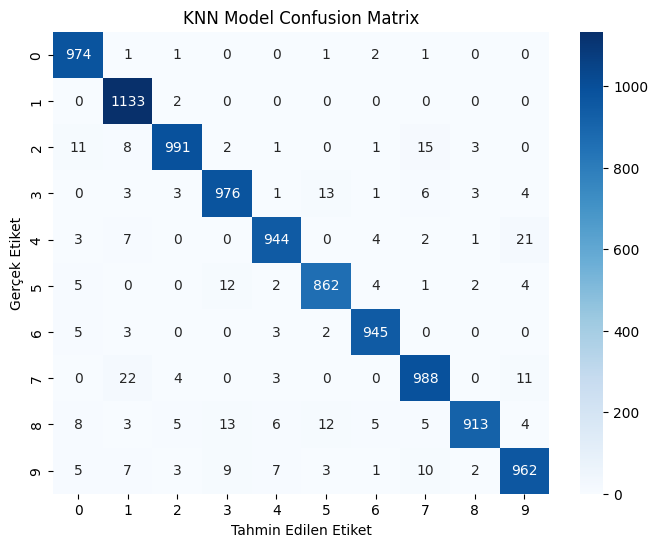

In [28]:
# KNN için confusion matrix oluşturma
cm_knn = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.title('KNN Model Confusion Matrix')
plt.show()

### Random Forest Modelinin Yeniden Eğitilmesi ve Confusion Matrix

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest modelini oluşturun ve eğitin
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Random Forest model eğitiliyor...")
rf_model.fit(X_train_normalized, y_train)
print("Random Forest model eğitimi tamamlandı.")

# Eğitim ve test setleri üzerinde tahminler yapın
y_train_pred_rf = rf_model.predict(X_train_normalized)
y_test_pred_rf = rf_model.predict(X_test_normalized)

# Modelin performansını değerlendirin
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"Random Forest Eğitim seti doğruluk skoru: {train_accuracy_rf:.4f}")
print(f"Random Forest Test seti doğruluk skoru: {test_accuracy_rf:.4f}")

Random Forest model eğitiliyor...
Random Forest model eğitimi tamamlandı.
Random Forest Eğitim seti doğruluk skoru: 1.0000
Random Forest Test seti doğruluk skoru: 0.9704


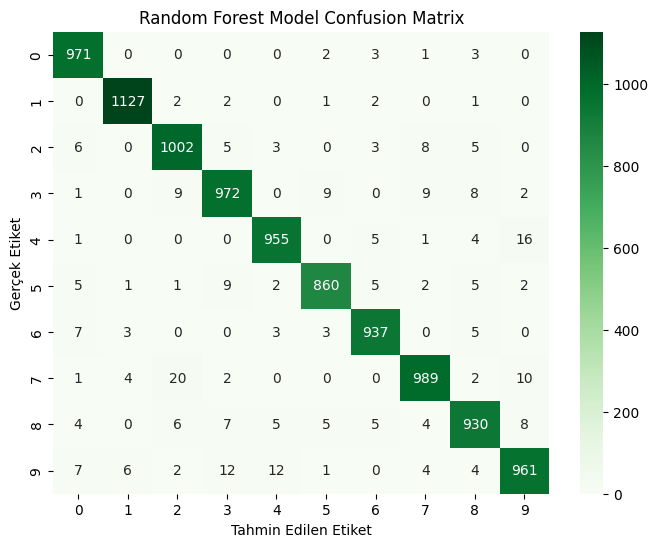

In [30]:
# Random Forest için confusion matrix oluşturma
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Tahmin Edilen Etiket')
plt.ylabel('Gerçek Etiket')
plt.title('Random Forest Model Confusion Matrix')
plt.show()